In [1]:

import matplotlib.pyplot as plt
import numpy as np
import yaml

with open("config.yaml", 'r') as y:
    config = yaml.safe_load(y)

PREDICTIONS = config["output"]["predictions_path"]

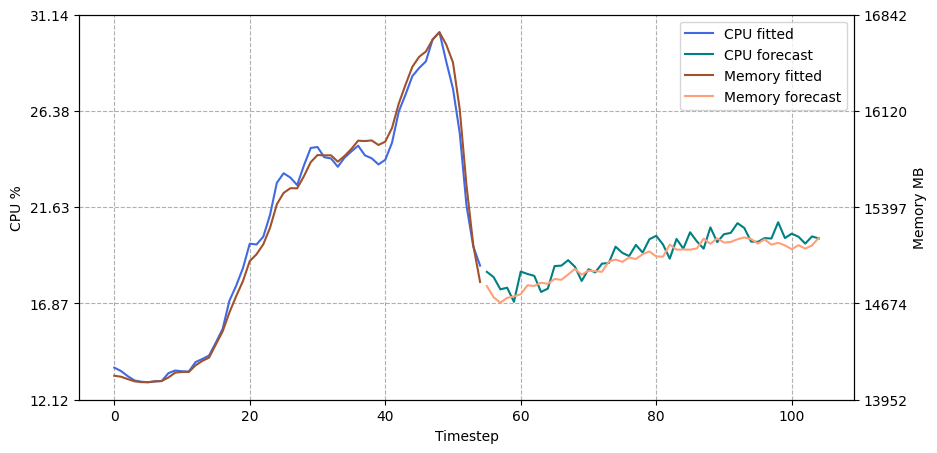

In [2]:
data = np.genfromtxt(PREDICTIONS, delimiter=',', skip_header=1, dtype=None, encoding=None)
history = np.array([[r[0], r[1], r[2]] for r in data if r[3] == False], dtype=float)
forecast = np.array([[r[0], r[1], r[2]] for r in data if r[3] == True], dtype=float)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(history[:, 0], history[:, 1], color="royalblue", label="CPU fitted")
ax1.plot(forecast[:, 0], forecast[:, 1], color="teal", label="CPU forecast")
ax2.plot(history[:, 0], history[:, 2], color="sienna", label="Memory fitted")
ax2.plot(forecast[:, 0], forecast[:, 2], color="lightsalmon", label="Memory forecast")

ax1.set_yticks(np.linspace(ax1.get_ylim()[0],ax1.get_ylim()[1], 5))
ax2.set_yticks(np.linspace(ax2.get_ylim()[0],ax2.get_ylim()[1], 5))

ax1.set_xlabel("Timestep")
ax1.set_ylabel("CPU %")
ax2.set_ylabel("Memory MB")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines])
ax1.grid(True, linestyle="--")